# DTLZ3
---

**Description**:

- Optimization (min)
- Multi-objective (M = 3)
---

The equations are given (for $M = 3$) by:

\begin{cases}
      f_{1}\left(\mathbf{x}\right) = \left(1 + g(\mathbf{x_M})\right) \cos(x_1\pi / 2) \cos(x_2 \pi / 2)\\
      f_{2}\left(\mathbf{x}\right) = \left(1 + g(\mathbf{x_M})\right) \cos(x_1\pi / 2) \sin(x_2 \pi / 2)\\
      f_{3}\left(\mathbf{x}\right) = \left(1 + g(\mathbf{x_M})\right) \sin(x_1 \pi / 2)\\
\end{cases}

subject to:

$ 0\le x_i \le 1$, for $i = 1, 2, ..., n$.

The last $k = (n - M + 1)$ variables are represented as $\mathbf{x_M}$. The suggested $g(\mathbf{x}) \ge 0$ is given by:

$g(\mathbf{x_M}) = 100\times\bigg[k + \sum_{x_i \in \mathbf{x_M}} (x_i - 0.5)^2 - \cos(20 \pi (x_i - 0.5)) \bigg]$.

---
*Citation:*

    K. Deb, L. Thiele, M. Laumanns and E. Zitzler, "Scalable multi-objective optimization test problems",
    Proceedings of the 2002 Congress on Evolutionary Computation. CEC'02 (Cat. No.02TH8600), HI, USA, 2002,
    pp. 825-830 vol.1, doi: 10.1109/CEC.2002.1007032.

### First we import Python libraries and set up the directory of our code

In [1]:
import os, sys
import itertools

import numpy as np
from numpy.typing import NDArray
from scipy.spatial import cKDTree
from matplotlib import pyplot as plt

PROJECT_DIR = os.path.abspath('..')

if PROJECT_DIR not in sys.path:
    sys.path.append(PROJECT_DIR)

### Here we import all our custom GA code

In [2]:
# Import main classes.
from pygenalgo.genome.gene import Gene
from pygenalgo.genome.chromosome import Chromosome
from pygenalgo.utils.utilities import np_pareto_front, cost_function
from pygenalgo.engines.multi_objective_ga import MultiObjectiveGA, RunConfig

# Import Mutation Operator(s).
from pygenalgo.operators.mutation.random_mutator import RandomMutator

# Import Crossover Operator(s).
from pygenalgo.operators.crossover.uniform_crossover import UniformCrossover

# Import Selection Operator(s).
from pygenalgo.operators.selection.pareto_front_selector import ParetoFrontSelector

### Auxiliary method to measure the results

In [3]:
def nearest_distance_stats(ga_pf: NDArray, true_pf: NDArray) -> dict:
    """
    ga_pf: objective vectors (Pareto front) from PyGenAlgo,
           shape (n_size, m_obj).
    
    true_pf: objective vectors sampled from the true Pareto front,
             shape (k_size, m_obj).
    """
    # Ensure inputs are numpy arrays.
    ga_pf = np.asarray(ga_pf, float)
    true_pf = np.asarray(true_pf, float)

    tree = cKDTree(true_pf)
    dists, _ = tree.query(ga_pf, k=1)

    return {
        "mean__": float(dists.mean()),
        "median": float(np.median(dists)),
        "p90___": float(np.quantile(dists, 0.9)),
        "max___": float(dists.max()),
    }

### Define the multi-objective function

In [4]:
# Multi-objective function.
def dtlz3_objectives(x: NDArray) -> tuple[float, ...]:
    """
    Compute DTLZ3 objective values.

    Parameters
    ----------
    x : NDArray of floats.
        These are the decision variables of length N.
        Typically, N = k + M -1, where k is the DTLZ
        'tail length'.
        
        This implementation infers k from len(x):
        k = len(x) - M + 1

    Returns
    -------
    f : tuple of floats
        Objective vector of length M=3 (to be minimized).
    """
    # Fix the number of objectives.
    m_: int = 3
    
    # Get the number of decision variables.
    n_: int = len(x)
    
    # DTLZ uses: k = N - M + 1 and g depends on x[M-1 : N]
    k_: int = n_ - m_ + 1
    
    # g(x_M..x_N) = 100 * (k + sum_{i=M..N-1} ((x_i - 0.5)^2 - cos(20*pi*(x_i-0.5))) )
    g_sum: float = 0.0
    for i in range(m_ - 1, n_):
        t = x[i] - 0.5
        g_sum += (t * t) - np.cos(20.0 * np.pi * t)

    # Auxiliary functional value.
    gx: float = 100.0 * (k_ + g_sum)

    # Predefine half pi (once).
    half_pi: float = 0.5 * np.pi

    # Compute the three objectives.
    f1: float = (1.0 + gx) * np.cos(half_pi * x[0]) * np.cos(half_pi * x[1])
    f2: float = (1.0 + gx) * np.cos(half_pi * x[0]) * np.sin(half_pi * x[1])
    f3: float = (1.0 + gx) * np.sin(half_pi * x[0])

    return f1, f2, f3
# _end_def_

@cost_function(minimize=True)
def func_dtlz3(x_arr: Chromosome) -> tuple[tuple[float, ...], bool]:
    # Extract the gene values.
    x: list[float] = x_arr.values()
    
    # Return the tuple.
    return tuple(dtlz3_objectives(x)), False

### Here we set the GA parameters, such as number of genes, number of chromosomes, etc.

In [5]:
# Number of objective functions.
m_obj: int = 3
assert m_obj >= 2, "m_obj must be >= 2."

# Say k=5 => n_dim=7 decision variables.
k: int = 5
assert k > 0, "Inferred k must be positive."

# Set the number of dimensions.
n_dim: int = k + m_obj - 1
assert n_dim >= m_obj, "Need n_dim >= m_obj."

# Random number generator.
rng = np.random.default_rng(1821)

# Random boundary function: U[0, 1).
boundary_x = lambda: rng.random()

# Define the number of chromosomes.
n_pop = 250

# Initial random population.
population = [
    Chromosome([Gene(boundary_x(), boundary_x) for _ in range(n_dim) ])
    for _ in range(n_pop)
]

# Create the MultiObjectiveGA object that will carry on the optimization.
test_GA = MultiObjectiveGA(initial_pop=population,
                           fit_func=func_dtlz3,
                           select_op=ParetoFrontSelector(),
                           mutate_op=RandomMutator(0.15),
                           crossx_op=UniformCrossover())

### Optimization process

In [6]:
test_GA(config=RunConfig(epochs=2000, elitism=True, shuffle=True))

09/09/2026 09:09:22 INFO: Initial Avg. Fitness = [-216.8427 -214.4463 -354.5158]
09/09/2026 09:09:35 INFO: Final: Avg. Fitness = [-5.8345 -7.6643 -9.6224]


Elapsed time: 12.889 seconds.


### Compute the true Pareto front

In [7]:
def dtlz3_pareto_front_samples(num_points_per_dim: int = 50):
    """
    Auxiliary function that generates grid samples
    on the true DTLZ Pareto front.

    :param num_points_per_dim: Default is 50.
        
    :return: objective vectors f of length 3.
    """
    # Generate grid points.
    grid: list[float] = [
        i / (num_points_per_dim - 1)
        for i in range(num_points_per_dim)
    ]

    # Generate samples on the grid.
    samples: list[list[float]] = [
        dtlz3_objectives(x_var)
        for x_var in itertools.product(grid, repeat=2)
    ]

    return samples
# _end_def_

### Visualize the solution on the Pareto plot

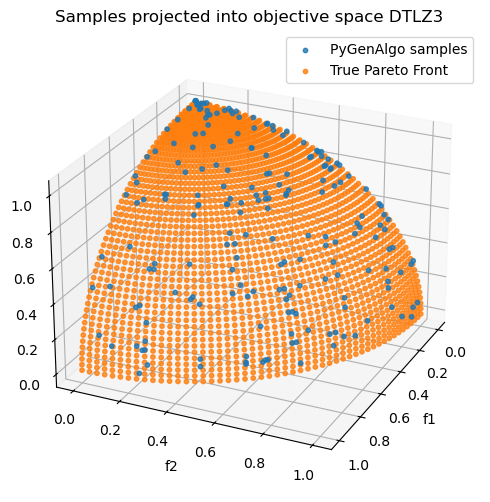

{'mean__': 0.013788505992635305,
 'median': 0.013107720399082062,
 'p90___': 0.018274345076755006,
 'max___': 0.022569267057458316}

In [8]:
# Extract all gene values.
x_all: NDArray = np.array([
    p.values()
    for p in test_GA.population
], dtype=float)

# Compute the objectives: (n_pop, 3)
f_all = np.array([
    dtlz3_objectives(x) for x in x_all
], dtype=float)

# Compute those on the Pareto front.
f_points = np_pareto_front(f_all, mode="min")

# Compute the true pareto front on a grid.
dtlz3_pf = np.array(dtlz3_pareto_front_samples())

# New figure.
fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(111, projection="3d")

ax.scatter(f_points[:, 0],
           f_points[:, 1],
           f_points[:, 2],
           s=10, alpha=0.8,
           label="PyGenAlgo samples")

ax.scatter(dtlz3_pf[:, 0],
           dtlz3_pf[:, 1],
           dtlz3_pf[:, 2],
           s=10, alpha=0.8,
           label="True Pareto Front")

# Adjust the viewing angle.
ax.view_init(elev=25, azim=25)

# Final labels.
ax.set_xlabel("f1")
ax.set_ylabel("f2")
ax.set_zlabel("f3")
ax.set_title("Samples projected into objective space DTLZ3")

plt.legend()
plt.show()

# Print statistics.
nearest_distance_stats(f_points, dtlz3_pf)

### End of file